# Pantheon+SH0ES — Distance Modulus vs Redshift
First look at the data and theoretical $\mu(z)$ curves before cosmological inference.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

## 1. Load Pantheon+SH0ES data

In [2]:
df = pd.read_csv('data/Pantheon+SH0ES.dat', sep='\s+', comment='#')

# Keep only Hubble-flow SNe (exclude Cepheid calibrators at very low z)
mask = (df['zHD'] > 0.01) & (df['IS_CALIBRATOR'] == 0)
z   = df.loc[mask, 'zHD'].values
mu  = df.loc[mask, 'MU_SH0ES'].values
mu_err = df.loc[mask, 'MU_SH0ES_ERR_DIAG'].values

print(f'Total SNe in file : {len(df)}')
print(f'After z>0.01 cut  : {len(z)}')
print(f'Redshift range    : {z.min():.4f} – {z.max():.4f}')
print(f'Columns available : {list(df.columns)}')

Total SNe in file : 1701
After z>0.01 cut  : 1580
Redshift range    : 0.0102 – 2.2614
Columns available : ['CID', 'IDSURVEY', 'zHD', 'zHDERR', 'zCMB', 'zCMBERR', 'zHEL', 'zHELERR', 'm_b_corr', 'm_b_corr_err_DIAG', 'MU_SH0ES', 'MU_SH0ES_ERR_DIAG', 'CEPH_DIST', 'IS_CALIBRATOR', 'USED_IN_SH0ES_HF', 'c', 'cERR', 'x1', 'x1ERR', 'mB', 'mBERR', 'x0', 'x0ERR', 'COV_x1_c', 'COV_x1_x0', 'COV_c_x0', 'RA', 'DEC', 'HOST_RA', 'HOST_DEC', 'HOST_ANGSEP', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_LOGMASS', 'HOST_LOGMASS_ERR', 'PKMJD', 'PKMJDERR', 'NDOF', 'FITCHI2', 'FITPROB', 'm_b_corr_err_RAW', 'm_b_corr_err_VPEC', 'biasCor_m_b', 'biasCorErr_m_b', 'biasCor_m_b_COVSCALE', 'biasCor_m_b_COVADD']


<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/sc/3sbv5zgs77zcpmwsqg_yfb500000gn/T/ipykernel_26673/936640287.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df = pd.read_csv('data/Pantheon+SH0ES.dat', sep='\s+', comment='#')


## 2. Theoretical distance modulus

For a flat ΛCDM cosmology:
$$\mu(z) = 5\log_{10}\left(\frac{d_L(z)}{10\,\text{pc}}\right) = 5\log_{10}\left(d_L / \text{Mpc}\right) + 25$$

where $d_L$ is the luminosity distance computed with `astropy`.

In [3]:
def mu_theory(z, H0, Om0):
    """Distance modulus for flat ΛCDM. Uses astropy for dL."""
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
    dL    = cosmo.luminosity_distance(z).to(u.Mpc).value   # Mpc
    return 5.0 * np.log10(dL) + 25.0

# Quick check at a few redshifts
z_test = np.array([0.1, 0.5, 1.0, 2.0])
print('Sanity check (H0=70, Om0=0.3):')
for zi, mui in zip(z_test, mu_theory(z_test, 70, 0.3)):
    print(f'  z={zi:.1f}  μ={mui:.3f}')

Sanity check (H0=70, Om0=0.3):
  z=0.1  μ=38.315
  z=0.5  μ=42.261
  z=1.0  μ=44.100
  z=2.0  μ=45.957


## 3. Hubble diagram — data + theoretical curves

<>:44: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
<>:44: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
/var/folders/sc/3sbv5zgs77zcpmwsqg_yfb500000gn/T/ipykernel_26673/2776577074.py:44: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
  ax.set_title('Pantheon+SH0ES Hubble Diagram — flat $\Lambda$CDM models', fontsize=13)


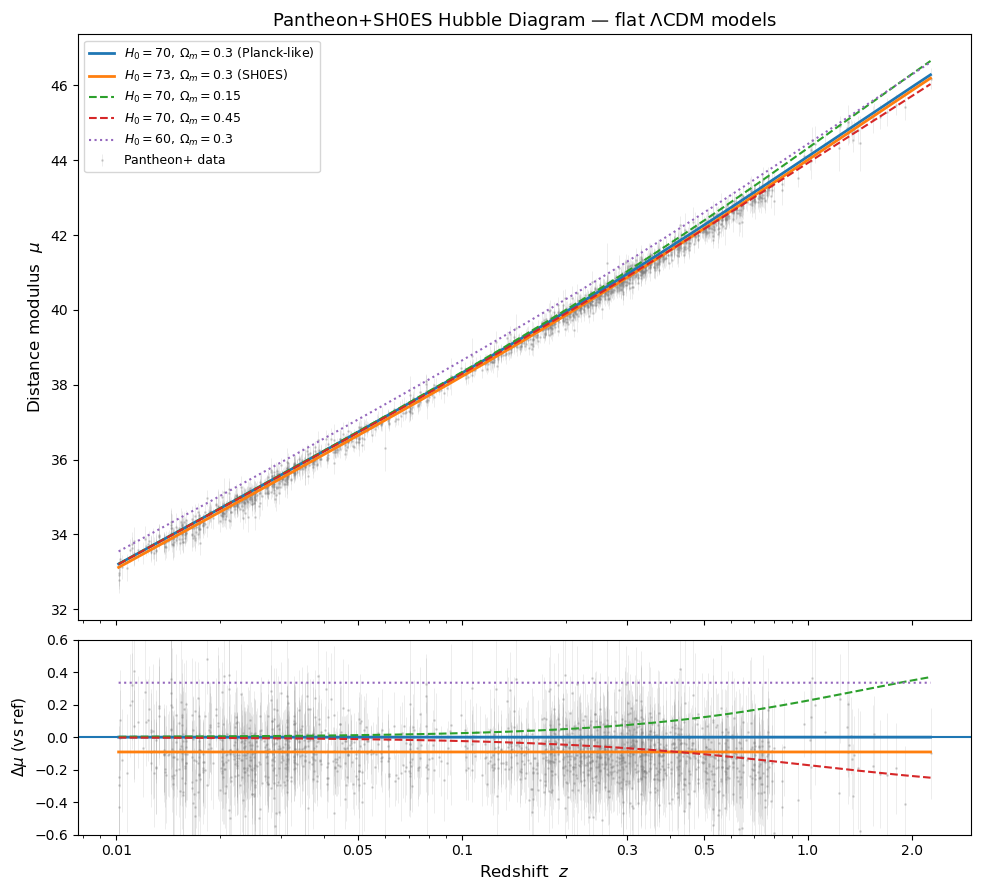

In [4]:
z_th = np.geomspace(z.min(), z.max(), 500)

# Cosmological models to compare
models = [
    dict(H0=70,  Om0=0.3,  label=r'$H_0=70,\,\Omega_m=0.3$ (Planck-like)', color='C0', lw=2.0),
    dict(H0=73,  Om0=0.3,  label=r'$H_0=73,\,\Omega_m=0.3$ (SH0ES)',       color='C1', lw=2.0),
    dict(H0=70,  Om0=0.15, label=r'$H_0=70,\,\Omega_m=0.15$',              color='C2', lw=1.5, ls='--'),
    dict(H0=70,  Om0=0.45, label=r'$H_0=70,\,\Omega_m=0.45$',              color='C3', lw=1.5, ls='--'),
    dict(H0=60,  Om0=0.3,  label=r'$H_0=60,\,\Omega_m=0.3$',               color='C4', lw=1.5, ls=':'),
]

fig, axes = plt.subplots(2, 1, figsize=(10, 9),
                          gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

ax, ax_res = axes

# ── Data ──────────────────────────────────────────────────────────────────────
ax.errorbar(z, mu, yerr=mu_err, fmt='.', color='gray', alpha=0.25,
            ms=2, elinewidth=0.4, capsize=0, label='Pantheon+ data', zorder=1)

# Reference model for residuals
ref_H0, ref_Om0 = 70, 0.3
mu_ref = mu_theory(z, ref_H0, ref_Om0)

# ── Theory curves ─────────────────────────────────────────────────────────────
for m in models:
    mu_th = mu_theory(z_th, m['H0'], m['Om0'])
    ax.plot(z_th, mu_th, color=m['color'], lw=m['lw'],
            ls=m.get('ls', '-'), label=m['label'], zorder=3)
    # Residuals w.r.t. reference
    mu_th_at_z = mu_theory(z, m['H0'], m['Om0'])
    ax_res.plot(z, mu_th_at_z - mu_ref, color=m['color'],
                lw=m['lw'], ls=m.get('ls', '-'), zorder=3)

# ── Residuals panel: data ─────────────────────────────────────────────────────
ax_res.errorbar(z, mu - mu_ref, yerr=mu_err, fmt='.', color='gray',
                alpha=0.25, ms=2, elinewidth=0.4, capsize=0, zorder=1)
ax_res.axhline(0, color='C0', lw=1.5, ls='-')
ax_res.set_ylabel(r'$\Delta\mu$ (vs ref)', fontsize=11)
ax_res.set_xlabel('Redshift  $z$', fontsize=12)
ax_res.set_ylim(-0.6, 0.6)

ax.set_ylabel(r'Distance modulus  $\mu$', fontsize=12)
ax.set_title('Pantheon+SH0ES Hubble Diagram — flat $\Lambda$CDM models', fontsize=13)
ax.legend(fontsize=9, loc='upper left')
ax.set_xscale('log')
ax_res.set_xscale('log')
ax_res.set_xticks([0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0])
ax_res.set_xticklabels(['0.01', '0.05', '0.1', '0.3', '0.5', '1.0', '2.0'])

plt.tight_layout()
plt.savefig('hubble_diagram.png', dpi=130, bbox_inches='tight')
plt.show()

## 4. Effect of H₀ and Ωₘ separately

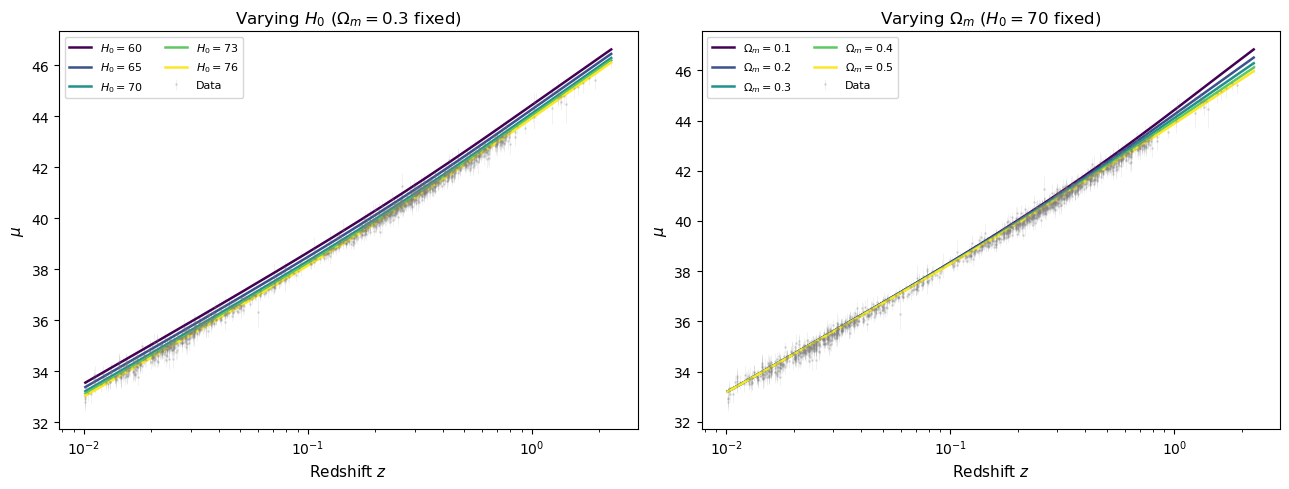

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, vary, fixed_label, series in [
    (axes[0], 'H0',  r'$\Omega_m=0.3$',
     [(60, 0.3), (65, 0.3), (70, 0.3), (73, 0.3), (76, 0.3)]),
    (axes[1], 'Om0', r'$H_0=70$',
     [(70, 0.1), (70, 0.2), (70, 0.3), (70, 0.4), (70, 0.5)]),
]:
    ax.errorbar(z, mu, yerr=mu_err, fmt='.', color='gray',
                alpha=0.2, ms=2, elinewidth=0.4, capsize=0, label='Data')
    cmap = plt.cm.viridis
    for k, (H0, Om0) in enumerate(series):
        color = cmap(k / (len(series) - 1))
        lbl = f'$H_0={H0}$' if vary == 'H0' else f'$\\Omega_m={Om0}$'
        ax.plot(z_th, mu_theory(z_th, H0, Om0), color=color, lw=1.8, label=lbl)
    ax.set_xscale('log')
    ax.set_xlabel('Redshift $z$', fontsize=11)
    ax.set_ylabel(r'$\mu$', fontsize=11)
    ax.set_title(f'Varying ${"{H_0}" if vary=="H0" else "\\Omega_m"}$ ({fixed_label} fixed)')
    ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('parameter_effect.png', dpi=130, bbox_inches='tight')
plt.show()